# 🌟 Обучение Модели С (Графовая Нейросеть GNN) — Google Colab

Этот блокнот предназначен для запуска полноценного цикла обучения продвинутой **Model C (GNN)** на датасете PTB-XL в среде Google Colab с использованием GPU.

**Какие SOTA-подходы здесь реализованы:**
1. **Model Architecture**: Чистый PyTorch GAT (Multi-head Graph Attention).
2. **Clinical Adjacency Graph**: Матрица смежности построена строго по медицинским правилам (Законы Эйнтховена, нижние/боковые отведения). Это мощнейший индуктивный сдвиг!
3. **LayerNorm + ELU**: Оптимизация специально для малых молекулярных/сенсорных графов (12 узлов/отведений), так как BatchNorm на таком размере нестабилен.
4. **Learning Rate Scheduler**: Оптимальный шаг обучения с Linear Warmup и CosineAnnealing.
5. **Абсолютные пути**: Прямое сохранение весов и CSV-логов в Google Drive, чтобы данные не пропали.

In [1]:
# ШАГ 1: Подключаем Google Диск
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ШАГ 2: Переходим в папку проекта на Диске
import os

project_path = '/content/drive/MyDrive/ecg-diploma'  
if os.path.exists(project_path):
    os.chdir(project_path)
    print("✅ Успешно перешли в директорию:", os.getcwd())
else:
    print("❌ Папка не найдена. Проверьте путь:", project_path)

!ls -la

✅ Успешно перешли в директорию: /content/drive/MyDrive/ecg-diploma
total 58
-rw------- 1 root root  262 Dec 20 12:43 CODEOWNERS
-rw------- 1 root root 2284 Dec 20 12:43 CONTRIBUTING.md
drwx------ 2 root root 4096 Jan 12 17:22 data_preprocessed
drwx------ 2 root root 4096 Mar 23 13:48 experiments
drwx------ 2 root root 4096 Mar 26 09:43 .git
drwx------ 2 root root 4096 Dec 20 12:43 .github
-rw------- 1 root root 5064 Dec 20 12:43 .gitignore
drwx------ 2 root root 4096 Mar 26 10:25 notebooks
-rw------- 1 root root 5452 Jan 12 18:25 README.md
-rw------- 1 root root 1056 Jan 12 17:34 requirements.txt
drwx------ 2 root root 4096 Mar 28 09:57 results
-rw------- 1 root root   38 Dec 20 12:43 results_summary.csv
-rw------- 1 root root 6019 Jan 12 18:25 SETUP.md
drwx------ 2 root root 4096 Dec 20 12:43 splits
drwx------ 5 root root 4096 Mar 28 09:57 src
drwx------ 2 root root 4096 Jan 12 17:00 .venv


In [3]:
# ШАГ 3: Установка зависимостей
!pip install -q -r requirements.txt
print("✅ Зависимости проверены/установлены!")

✅ Зависимости проверены/установлены!


In [4]:
# ШАГ 5: ПОЛНЫЙ ЗАПУСК ОБУЧЕНИЯ НА GPU
!python -m src.train --model model_c_gnn \
    --epochs 60 \
    --batch_size 64 \
    --accum_steps 2 \
    --warmup_epochs 5 \
    --label_smoothing 0.1 \
    --num_workers 2 \
    --patience 12 \
    --use_weighted_sampler \
    --output_dir /content/drive/MyDrive/ecg-diploma/results

✅ Global seed set: 42

  PTB-XL SOTA Training v2.0 — MODEL_C_GNN
  Device          : cuda  [AMP ON]
  Batch size      : 64 × 2 accum = 128 effective
  LR schedule     : Warmup(5ep) → CosineAnnealing
  Label smoothing : 0.1
  Epochs          : 60  |  Patience: 12
  Output          : /content/drive/MyDrive/ecg-diploma/results/model_c_gnn
  Resume          : NO ← новое обучение

─────────────────────────────────────────────────────────────────
✅ Global seed set: 42
✅ Loaded train split: 17418 samples
   Signal shape: (12, 1000)
   Classes: ['NORM', 'MI', 'STTC', 'CD', 'HYP']
   Augmentation: ON
   Label distribution:
     NORM: 7596 (43.6%)
     MI: 4379 (25.1%)
     STTC: 4087 (23.5%)
     CD: 3907 (22.4%)
     HYP: 2119 (12.2%)
✅ Loaded val split: 2183 samples
   Signal shape: (12, 1000)
   Classes: ['NORM', 'MI', 'STTC', 'CD', 'HYP']
   Augmentation: OFF
   Label distribution:
     NORM: 955 (43.7%)
     MI: 540 (24.7%)
     STTC: 515 (23.6%)
     CD: 495 (22.7%)
     HYP: 268 (12.3%)


✅ Логи найдены по пути: /content/drive/MyDrive/ecg-diploma/results/model_c_gnn


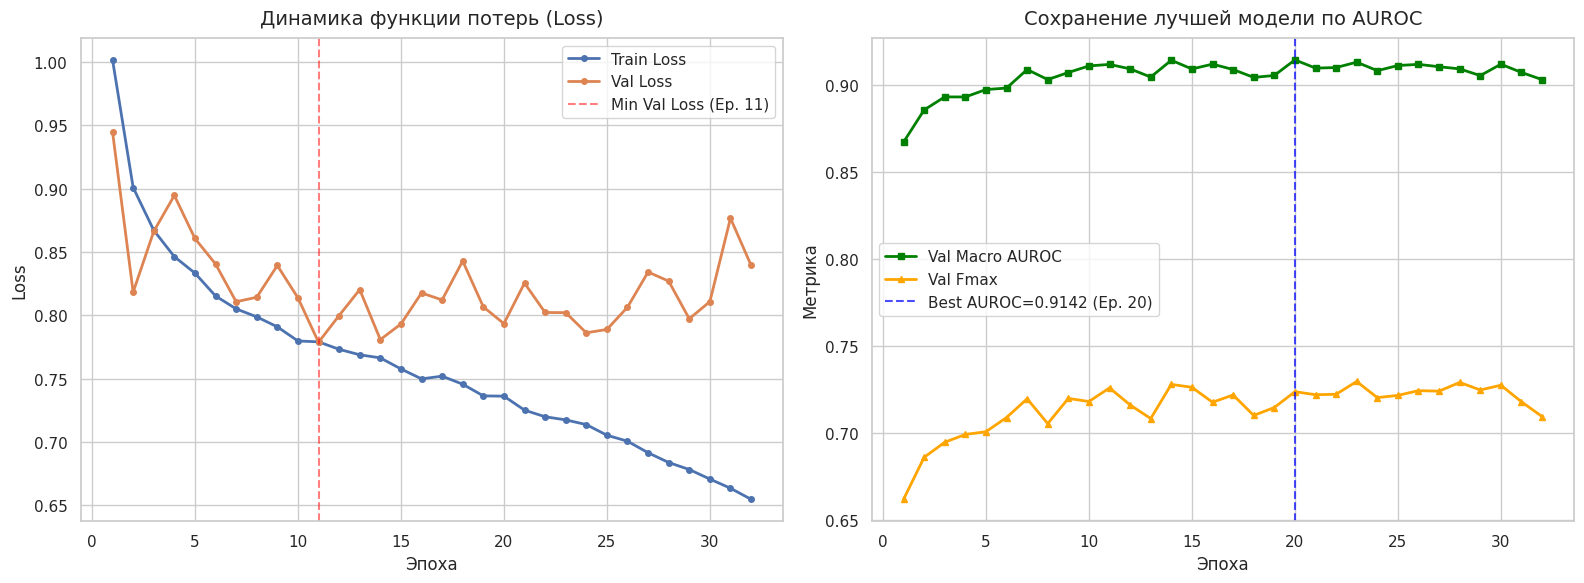


 🏆 ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ (TEST SET) 🏆
 🔸 Macro AUROC: 0.9053
 🔸 Micro AUROC: 0.8901
 🔸 AUPRC:       0.7690
 🔸 Fmax:        0.7130
 🔸 F1 (Macro):  0.6601


In [5]:
# ШАГ 6: ВИЗУАЛИЗАЦИЯ ПРОЦЕССА ОБУЧЕНИЯ
# Если вы уже обучили модель и перезапустили ядро, эту ячейку можно выполнять сразу
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path

# Список возможных путей, где могли сохраниться логи после всех перезапусков ядра
possible_roots = [
    Path(os.getcwd()) / 'results' / 'model_c_gnn',          # Если мы в корне проекта
    Path(os.getcwd()).parent / 'results' / 'model_c_gnn',   # Если мы в папке notebooks/
    Path('/content/results/model_c_gnn'),                   # Если мы в корне Colab
    Path('/content/drive/MyDrive/ecg-diploma/results/model_c_gnn'), # Старый путь Drive
    Path('/content/drive/MyDrive/ecg-diploma1/results/model_c_gnn'),# Ваш обновленный путь
    Path('C:/Users/Dimash/Desktop/ecg-diploma/ecg-diploma/results/model_c_gnn') # Локальный путь на Windows
]

# Ищем где реально лежат файлы
log_path = None
test_path = None
for p in possible_roots:
    if (p / 'train_log.csv').exists():
        log_path = p / 'train_log.csv'
        test_path = p / 'test_results.json'
        print(f"✅ Логи найдены по пути: {p}")
        break

if log_path and log_path.exists():
    df_log = pd.read_csv(log_path)
    
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- График 1: Функция потерь (Loss) ---
    ax1.plot(df_log['epoch'], df_log['train_loss'], label='Train Loss', marker='o', markersize=4, linewidth=2)
    ax1.plot(df_log['epoch'], df_log['val_loss'], label='Val Loss', marker='o', markersize=4, linewidth=2)
    ax1.set_title('Динамика функции потерь (Loss)', fontsize=14, pad=10)
    ax1.set_xlabel('Эпоха', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    
    best_loss_epoch = df_log.loc[df_log['val_loss'].idxmin(), 'epoch']
    ax1.axvline(best_loss_epoch, color='red', linestyle='--', alpha=0.5, label=f'Min Val Loss (Ep. {int(best_loss_epoch)})')
    ax1.legend(fontsize=11)

    # --- График 2: Метрики ---
    if 'val_macro_auc' in df_log.columns:
        ax2.plot(df_log['epoch'], df_log['val_macro_auc'], label='Val Macro AUROC', marker='s', markersize=4, color='green', linewidth=2)
        ax2.plot(df_log['epoch'], df_log['val_fmax'], label='Val Fmax', marker='^', markersize=4, color='orange', linewidth=2)
        ax2.set_title('Сохранение лучшей модели по AUROC', fontsize=14, pad=10)
        ax2.set_xlabel('Эпоха', fontsize=12)
        ax2.set_ylabel('Метрика', fontsize=12)
        
        best_auroc_epoch = int(df_log.loc[df_log['val_macro_auc'].idxmax(), 'epoch'])
        best_auroc = df_log['val_macro_auc'].max()
        ax2.axvline(best_auroc_epoch, color='blue', linestyle='--', alpha=0.7, label=f'Best AUROC={best_auroc:.4f} (Ep. {best_auroc_epoch})')
        ax2.legend(fontsize=11)

    plt.tight_layout()
    plt.show()
    
    # --- Вывод финальных результатов ---
    if test_path.exists():
        with open(test_path, 'r') as f:
            test_res = json.load(f)
        print("\n" + "="*45)
        print(" 🏆 ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ (TEST SET) 🏆")
        print("="*45)
        print(f" 🔸 Macro AUROC: {test_res.get('macro_auc', 0):.4f}")
        print(f" 🔸 Micro AUROC: {test_res.get('micro_auc', 0):.4f}")
        print(f" 🔸 AUPRC:       {test_res.get('macro_auprc', 0):.4f}")
        print(f" 🔸 Fmax:        {test_res.get('fmax', 0):.4f}")
        print(f" 🔸 F1 (Macro):  {test_res.get('f1_macro', 0):.4f}")
        print("="*45)
else:
    print("❌ ОШИБКА: Файл с логами не найден!")